# **Module 2.0: Feature Extraction and Object Detection**

**Advanced Feature Extraction and Image Processing**

**Exercise 1: Harris Corner Detection**

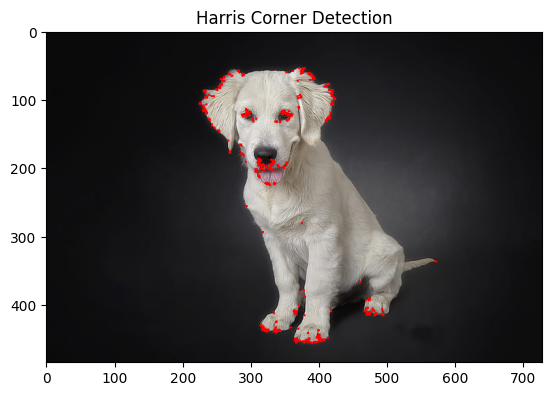

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('dog.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Harris corner detection
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, 2, 3, 0.04)

# Dilate corner img to enhance the corner points
dst = cv2.dilate(dst, None)

# Threshold for marking corners
img[dst > 0.01 * dst.max()] = [0, 0, 255]

# Display result
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Harris Corner Detection')
plt.show()

**Exercise 2: HOG (Histogram of Oriented Gradients) Feature Extraction**

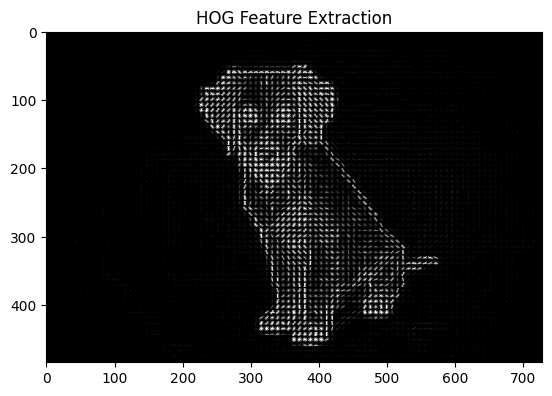

In [5]:
import cv2
from skimage.feature import hog
import matplotlib.pyplot as plt
from skimage import exposure

# Load img
img = cv2.imread('dog.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# HOG feature extraction
hog_features, hog_image = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')

# Rescale HOG img for better visualization
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# Display HOG
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title('HOG Feature Extraction')
plt.show()

**Exercise 3: FAST (Features from Accelerated Segment Test) Keypoint Detection**

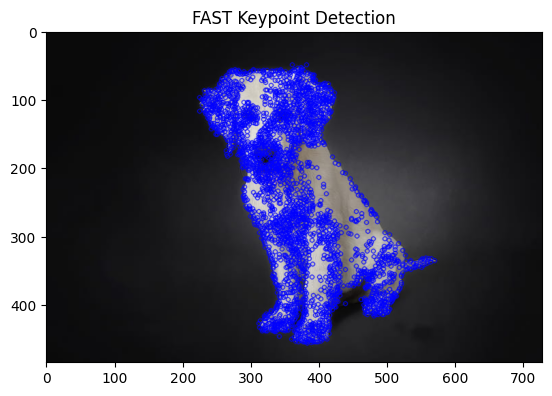

In [6]:
import cv2
import matplotlib.pyplot as plt

# Load img
img = cv2.imread('dog.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# FAST keypoint detector
fast = cv2.FastFeatureDetector_create()
keypoints = fast.detect(gray, None)

# Draw keypoints
image_with_keypoints = cv2.drawKeypoints(img, keypoints, None, color=(255, 0, 0))

# Display result
plt.imshow(cv2.cvtColor(image_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title('FAST Keypoint Detection')
plt.show()

**Exercise 4: Feature Matching using ORB and FLANN**

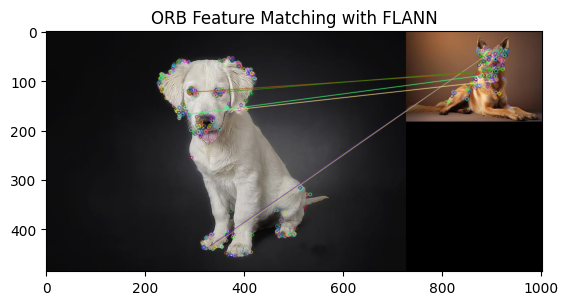

In [13]:
import cv2
import matplotlib.pyplot as plt

# Load two images
img1 = cv2.imread('dog.jpg')
img2 = cv2.imread('dog1.jpg')

# Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# ORB detector
orb = cv2.ORB_create()

# Find keypoints and descriptors
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# FLANN-based matcher parameters
index_params = dict(algorithm=6, table_number=6, key_size=12, multi_probe_level=1)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(des1, des2, k=2)

# Apply ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

# Draw matches
result_image = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None)

# Display result
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.title('ORB Feature Matching with FLANN')
plt.show()

**Exercise 5: Image Segmentation using Watershed Algorithm**

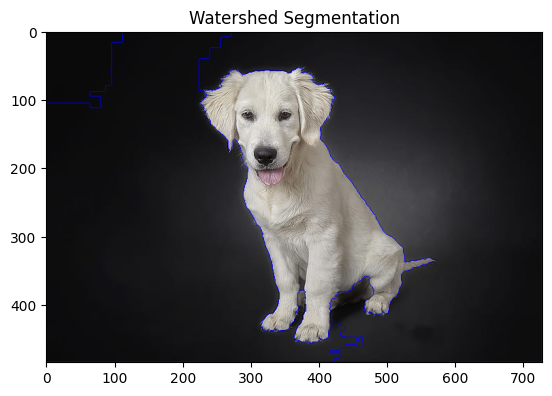

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('dog.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Convert img to binary using threshold
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Noise removal using morphology
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

# background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# Unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labeling
_, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

# Mark the unknown region with zero
markers[unknown == 255] = 0

# Apply Watershed
markers = cv2.watershed(img, markers)
img[markers == -1] = [255, 0, 0]

# Display result
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Watershed Segmentation')
plt.show()